# 12 – Bootstrap CIs, Performance Curves & Forest Plot

Computes 95% bootstrap confidence intervals for all model metrics and a paired bootstrap
test between the two fusion models, and draws the performance figures used in the report
(ROC, precision-recall, metric bar chart, calibration curves, and the AUROC forest plot).

**Run after notebooks 08, 09a, 10, 11** — uses their saved predictions
(preds_signal.npz, preds_text.npz, preds_concat.npz, preds_crossattn.npz).

**Produces:** confidence-interval table and paired-test results (printed inline);
figures:
fig_roc.png (Fig 4.5), fig_pr.png (Fig 4.6), fig_bar.png (Fig 4.7),
fig_cal.png (Fig 4.8), forest_auroc.png (Fig 4.9).

Predictions are model outputs only (no patient-level data), so no data-access restrictions
apply to this notebook.

In [ ]:
# --- Setup ---
import os

try:
    from config import DATA_DIR
except ImportError:
    DATA_DIR = os.environ.get("ERP_DATA_DIR", "./data")

def data_path(name):
    return os.path.join(DATA_DIR, name)


In [ ]:
import numpy as np
from sklearn.metrics import roc_auc_score, average_precision_score, f1_score
B, THRESH, SEED = 2000, 0.5, 42

def metrics(yt, yp):
    return (roc_auc_score(yt, yp), average_precision_score(yt, yp),
            f1_score(yt, (yp >= THRESH).astype(int), zero_division=0))

def ci_single(yt, yp, B=B, seed=SEED):
    yt, yp = np.asarray(yt), np.asarray(yp); n = len(yt)
    rng = np.random.default_rng(seed); au, ap, f = [], [], []
    for _ in range(B):
        idx = rng.integers(0, n, n); y = yt[idx]
        if y.min() == y.max(): continue
        a = metrics(y, yp[idx]); au.append(a[0]); ap.append(a[1]); f.append(a[2])
    pt = metrics(yt, yp); pct = lambda a: (np.percentile(a, 2.5), np.percentile(a, 97.5))
    return {"AUROC": (pt[0], *pct(au)), "AUPRC": (pt[1], *pct(ap)), "F1": (pt[2], *pct(f))}

def ci_paired(yt, pa, pb, B=B, seed=SEED):
    yt, pa, pb = np.asarray(yt), np.asarray(pa), np.asarray(pb); n = len(yt)
    rng = np.random.default_rng(seed); dau, dap, df = [], [], []
    for _ in range(B):
        idx = rng.integers(0, n, n); y = yt[idx]
        if y.min() == y.max(): continue
        a = metrics(y, pa[idx]); b = metrics(y, pb[idx])
        dau.append(a[0]-b[0]); dap.append(a[1]-b[1]); df.append(a[2]-b[2])
    A, Bm = metrics(yt, pa), metrics(yt, pb)
    pct = lambda a: (np.percentile(a, 2.5), np.percentile(a, 97.5))
    return {"AUROC": (A[0]-Bm[0], *pct(dau)), "AUPRC": (A[1]-Bm[1], *pct(dap)), "F1": (A[2]-Bm[2], *pct(df))}

files = {"Signals-only (LSTM)": "preds_signal.npz",
         "Text-only (fine-tuned)": "preds_text.npz",
         "Concatenation fusion": "preds_concat.npz",
         "Cross-attention fusion": "preds_crossattn.npz"}
D = {}
resluts = {}
print(f"{'Model':<26}{'AUROC (95% CI)':<28}{'AUPRC (95% CI)':<28}{'F1 (95% CI)'}")
for name, fn in files.items():
    z = np.load(data_path(fn), allow_pickle=True)
    D[name] = (z["stay_ids"], z["y_true"], z["y_prob"])
    r = ci_single(z["y_true"], z["y_prob"])
    results[name] = r
    fmt = lambda m: f"{r[m][0]:.3f} [{r[m][1]:.3f}, {r[m][2]:.3f}]"
    print(f"{name:<26}{fmt('AUROC'):<28}{fmt('AUPRC'):<28}{fmt('F1')}")

s_ca, yt_ca, yp_ca = D["Cross-attention fusion"]
s_co, yt_co, yp_co = D["Concatenation fusion"]
order = {s: i for i, s in enumerate(s_co)}
perm = [order[s] for s in s_ca]                       # align concat to cross-attn by stay_id
assert np.array_equal(yt_ca, yt_co[perm]), "labels mismatch after alignment!"
d = ci_paired(yt_ca, yp_ca, yp_co[perm])
print("\nPaired difference (cross-attention − concatenation):")
for m in ("AUROC", "AUPRC", "F1"):
    p, lo, hi = d[m]; tag = "crosses 0 → not reliable" if lo <= 0 <= hi else "excludes 0"
    print(f"  {m}: {p:+.3f} [{lo:+.3f}, {hi:+.3f}]  ({tag})")

Model                     AUROC (95% CI)              AUPRC (95% CI)              F1 (95% CI)
Signals-only (LSTM)       0.675 [0.641, 0.708]        0.379 [0.330, 0.434]        0.413 [0.371, 0.456]
Text-only (fine-tuned)    0.669 [0.637, 0.701]        0.337 [0.292, 0.391]        0.397 [0.358, 0.434]
Concatenation fusion      0.786 [0.756, 0.815]        0.507 [0.448, 0.569]        0.487 [0.449, 0.524]
Cross-attention fusion    0.794 [0.765, 0.821]        0.512 [0.455, 0.573]        0.515 [0.475, 0.554]

Paired difference (cross-attention − concatenation):
  AUROC: +0.008 [-0.004, +0.020]  (crosses 0 → not reliable)
  AUPRC: +0.005 [-0.019, +0.030]  (crosses 0 → not reliable)
  F1: +0.028 [+0.007, +0.048]  (excludes 0)


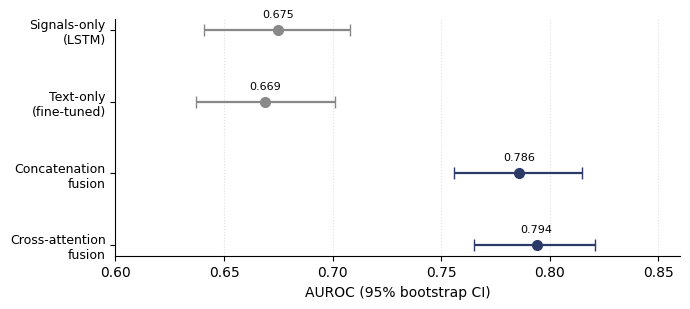

In [ ]:
import matplotlib.pyplot as plt

models = ["Signals-only\n(LSTM)", "Text-only\n(fine-tuned)",
          "Concatenation\nfusion", "Cross-attention\nfusion"]
result_names = ["Signals-only (LSTM)", "Text-only (fine-tuned)", "Concatenation fusion", "Cross-attention fusion"]

point = [results[name]["AUROC"][0] for name in result_names]

lo = [results[name]["AUROC"][1] for name in result_names]

hi = [results[name]["AUROC"][2] for name in result_names]

y = list(range(len(models)))[::-1]
err_low  = [p - l for p, l in zip(point, lo)]
err_high = [h - p for p, h in zip(point, hi)]
colors = ["#888888", "#888888", "#2b3a67", "#2b3a67"]   # baselines grey, fusion dark

fig, ax = plt.subplots(figsize=(7, 3.2))
for yi, p, el, eh, c in zip(y, point, err_low, err_high, colors):
    ax.errorbar(p, yi, xerr=[[el], [eh]], fmt='o', color=c,
                ecolor=c, elinewidth=1.6, capsize=4, markersize=7)
    ax.text(p, yi + 0.18, f"{p:.3f}", ha='center', fontsize=8)

ax.set_yticks(y); ax.set_yticklabels(models, fontsize=9)
ax.set_xlabel("AUROC (95% bootstrap CI)", fontsize=10)
ax.set_xlim(0.60, 0.86)
ax.grid(axis='x', ls=':', color='lightgrey', alpha=0.7)
for s in ['top', 'right']: ax.spines[s].set_visible(False)
plt.tight_layout()
plt.savefig("forest_auroc.png", dpi=200, bbox_inches='tight')
plt.show()

In [ ]:
# ===== Figures 4.5–4.8: ROC, PR, metric bars, calibration =====
import numpy as np
import matplotlib.pyplot as plt
from sklearn.metrics import (roc_curve, precision_recall_curve,
                             roc_auc_score, average_precision_score)
from sklearn.calibration import calibration_curve

files = {
    "Signals-only (LSTM)":     "preds_signal.npz",
    "Text-only (fine-tuned)":  "preds_text.npz",
    "Concatenation fusion":    "preds_concat.npz",
    "Cross-attention fusion":  "preds_crossattn.npz",
}
colors = {
    "Signals-only (LSTM)":    "#888888",
    "Text-only (fine-tuned)": "#bbbbbb",
    "Concatenation fusion":   "#2b3a67",
    "Cross-attention fusion": "#c1121f",
}

D = {}
for name, fn in files.items():
    z = np.load(data_path(fn), allow_pickle=True)
    D[name] = (z["y_true"], z["y_prob"])

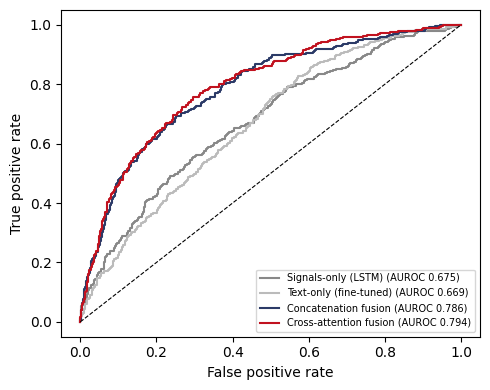

In [ ]:
# --- Figure 4.5: ROC curves ---
plt.figure(figsize=(5, 4))
for name, (y, p) in D.items():
    fpr, tpr, _ = roc_curve(y, p)
    plt.plot(fpr, tpr, color=colors[name],
             label=f"{name} (AUROC {roc_auc_score(y, p):.3f})")
plt.plot([0, 1], [0, 1], "k--", lw=0.8)
plt.xlabel("False positive rate"); plt.ylabel("True positive rate")
plt.legend(fontsize=7, loc="lower right")
plt.tight_layout(); plt.savefig("fig_roc.png", dpi=300, bbox_inches="tight"); plt.show()

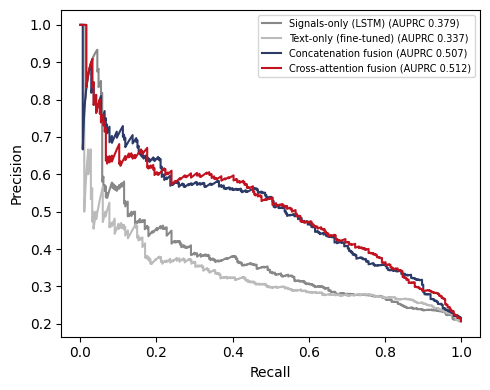

In [ ]:
# --- Figure 4.6: Precision-Recall curves ---
plt.figure(figsize=(5, 4))
for name, (y, p) in D.items():
    pr, rc, _ = precision_recall_curve(y, p)
    plt.plot(rc, pr, color=colors[name],
             label=f"{name} (AUPRC {average_precision_score(y, p):.3f})")
plt.xlabel("Recall"); plt.ylabel("Precision")
plt.legend(fontsize=7, loc="upper right")
plt.tight_layout(); plt.savefig("fig_pr.png", dpi=300, bbox_inches="tight"); plt.show()

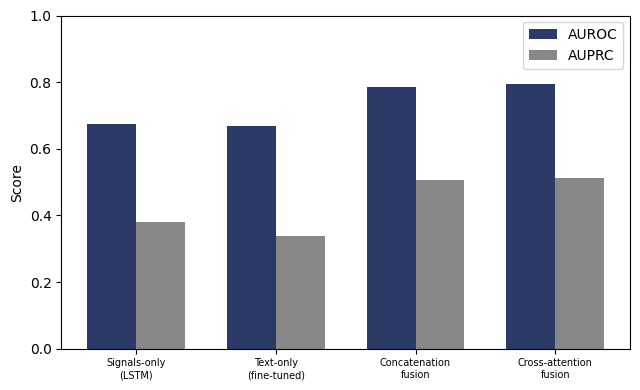

In [ ]:
# --- Figure 4.7: AUROC and AUPRC bar chart ---
names = list(D.keys())
auroc = [roc_auc_score(*D[n]) for n in names]
auprc = [average_precision_score(*D[n]) for n in names]
x = np.arange(len(names)); w = 0.35
plt.figure(figsize=(6.5, 4))
plt.bar(x - w/2, auroc, w, label="AUROC", color="#2b3a67")
plt.bar(x + w/2, auprc, w, label="AUPRC", color="#888888")
plt.xticks(x, [n.replace(" ", "\n") for n in names], fontsize=7)
plt.ylabel("Score"); plt.ylim(0, 1); plt.legend()
plt.tight_layout(); plt.savefig("fig_bar.png", dpi=300, bbox_inches="tight"); plt.show()

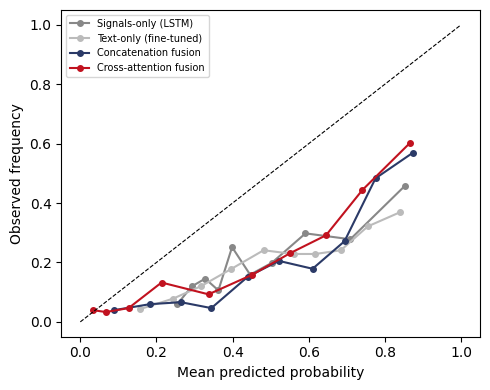

In [ ]:
# --- Figure 4.8: Calibration (reliability) curves ---
plt.figure(figsize=(5, 4))
for name, (y, p) in D.items():
    frac, mean = calibration_curve(y, p, n_bins=10, strategy="quantile")
    plt.plot(mean, frac, "o-", color=colors[name], markersize=4, label=name)
plt.plot([0, 1], [0, 1], "k--", lw=0.8)
plt.xlabel("Mean predicted probability"); plt.ylabel("Observed frequency")
plt.legend(fontsize=7, loc="upper left")
plt.tight_layout(); plt.savefig("fig_cal.png", dpi=300, bbox_inches="tight"); plt.show()